# พลอตข้อมูลพายุยางิ
* ใช้เรดาร์ uf สถานีเชียงราย
* พลอต ppi แปลงเป็นกริด พลอตในพิกัดภูมิศาสตร์
* ปรับแก้ quality control แล้วนำมาทำ cappi

In [1]:
!pip install -q arm-pyart
!pip install -q rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.6/199.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 65.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025

In [10]:
# Single CRI Radar 15-min CAPPI Processor with Quality Control, File Checking, and PPI Mapping
# Based on Dr. Nattapon Mahavik's research code
# Modified for single file processing in Google Colab with enhanced PPI plotting

import os
import tempfile
import shutil
import numpy as np
import pyart
import xarray as xr
import rioxarray
from datetime import datetime
import copy
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import warnings
from scipy.ndimage import label
from google.colab import drive, files
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Install required packages if needed
try:
    import cartopy
except ImportError:
    !pip install cartopy

# Suppress warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pyart.map.gates_to_grid")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="Mean of empty slice")

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

def check_radar_file(file_path):
    """Check radar file properties and available fields"""
    print("="*60)
    print("RADAR FILE INSPECTION")
    print("="*60)

    if not os.path.exists(file_path):
        print(f"✗ File not found: {file_path}")
        return None

    print(f"File: {os.path.basename(file_path)}")
    print(f"Size: {os.path.getsize(file_path) / (1024*1024):.2f} MB")
    print(f"Path: {file_path}")

    # Try to read the file
    radar = try_read_radar_file(file_path)
    if radar is None:
        return None

    print("\n📡 RADAR SPECIFICATIONS:")
    print(f"  • Rays (azimuths): {radar.nrays}")
    print(f"  • Gates (range bins): {radar.ngates}")
    print(f"  • Sweeps (elevations): {radar.nsweeps}")
    print(f"  • Max range: {radar.range['data'][-1]/1000:.1f} km")

    # Radar location
    lat = radar.latitude['data'][0]
    lon = radar.longitude['data'][0]
    alt = radar.altitude['data'][0]
    print(f"  • Location: {lat:.6f}°N, {lon:.6f}°E")
    print(f"  • Altitude: {alt:.0f} m")

    # Elevation angles
    if radar.nsweeps > 1:
        elevations = [radar.elevation['data'][radar.sweep_start_ray_index['data'][i]] for i in range(radar.nsweeps)]
        print(f"  • Elevation angles: {[f'{el:.2f}°' for el in elevations]}")
    else:
        print(f"  • Elevation angle: {radar.elevation['data'][0]:.2f}°")

    # Time information
    try:
        scan_time = pyart.util.datetime_from_radar(radar)
        print(f"  • Scan time: {scan_time.strftime('%Y-%m-%d %H:%M:%S UTC')}")
    except Exception as e:
        print(f"  • Scan time: Not available ({str(e)[:30]}...)")

    print("\n🔍 AVAILABLE FIELDS:")
    for i, field in enumerate(radar.fields.keys(), 1):
        field_info = radar.fields[field]
        print(f"  {i:2d}. {field}")
        if 'long_name' in field_info:
            print(f"      └─ {field_info['long_name']}")
        if 'units' in field_info:
            print(f"      └─ Units: {field_info['units']}")

    print("="*60)
    return radar

def try_read_radar_file(file_path):
    """Robust radar file reader with automatic renaming"""
    print(f"Attempting to read: {os.path.basename(file_path)}")

    # Strategy 1: Try reading directly
    try:
        radar = pyart.io.read(file_path)
        print("✓ Direct read successful")
        return radar
    except Exception as e:
        print(f"⚠ Direct read failed: {str(e)[:60]}...")

    # Strategy 2: Try different extensions
    print("Trying file rename strategies...")

    extensions_to_try = ['.uf', '.UF', '.raw', '.vol', '']

    with tempfile.TemporaryDirectory() as temp_dir:
        original_name = os.path.basename(file_path)
        base_name = os.path.splitext(os.path.splitext(original_name)[0])[0]  # Remove all extensions

        for ext in extensions_to_try:
            try:
                temp_file_path = os.path.join(temp_dir, f"{base_name}{ext}")
                shutil.copy2(file_path, temp_file_path)

                print(f"  Trying extension: {ext if ext else '(no extension)'}")
                radar = pyart.io.read(temp_file_path)
                print(f"✓ SUCCESS with extension: {ext if ext else '(no extension)'}")
                return radar

            except Exception as e:
                continue

    # Strategy 3: Check if it's compressed
    try:
        import gzip
        with tempfile.NamedTemporaryFile(suffix='.uf') as temp_file:
            with gzip.open(file_path, 'rb') as gz_file:
                temp_file.write(gz_file.read())
                temp_file.flush()

            radar = pyart.io.read(temp_file.name)
            print("✓ SUCCESS! File was gzip compressed")
            return radar
    except Exception:
        pass

    print("✗ All reading strategies failed")
    return None

def plot_ppi_geographic(radar, sweep=0, field='reflectivity', title_suffix=""):
    """Plot PPI on geographic map with cartopy"""
    print(f"Creating PPI geographic plot for sweep {sweep}...")

    try:
        # Get radar location
        radar_lat = radar.latitude['data'][0]
        radar_lon = radar.longitude['data'][0]

        # Check if field exists
        if field not in radar.fields:
            available_fields = list(radar.fields.keys())
            print(f"Field '{field}' not found. Available fields: {available_fields}")
            field = available_fields[0]  # Use first available field
            print(f"Using field: {field}")

        # Set up the projection
        projection = ccrs.PlateCarree()

        # Create figure
        fig = plt.figure(figsize=(14, 12))

        # Create RadarMapDisplay
        display = pyart.graph.RadarMapDisplay(radar)

        # Calculate map bounds (approximately ±250 km from radar)
        lat_offset = 2.5  # approximately 250 km
        lon_offset = 2.5 / np.cos(np.radians(radar_lat))  # adjust for latitude

        min_lat = radar_lat - lat_offset
        max_lat = radar_lat + lat_offset
        min_lon = radar_lon - lon_offset
        max_lon = radar_lon + lon_offset

        # Plot PPI map
        display.plot_ppi_map(
            field, sweep,
            vmin=-10, vmax=50,  # Adjust these values based on your data
            min_lon=min_lon, max_lon=max_lon,
            min_lat=min_lat, max_lat=max_lat,
            lon_lines=np.arange(min_lon, max_lon, 1.0),
            lat_lines=np.arange(min_lat, max_lat, 0.5),
            resolution='50m',  # cartopy resolution
            projection=projection,
            fig=fig,
            lat_0=radar_lat,
            lon_0=radar_lon,
            colorbar_flag=True,
            colorbar_label=f"{radar.fields[field].get('units', 'dBZ')}"
        )

        # Add range rings
        range_rings = [50, 100, 150, 200, 250]  # km
        colors = ['white', 'gray', 'white', 'gray', 'white']
        styles = ['-', '--', '-', '--', '-']

        for i, (range_km, color, style) in enumerate(zip(range_rings, colors, styles)):
            display.plot_range_ring(range_km, line_style=f'{color[0]}{style}',
                                  lw=1.5, alpha=0.8)

        # Add cross hairs
        display.plot_line_xy(
            np.array([-250000.0, 250000.0]),
            np.array([0.0, 0.0]),
            line_style='w-', lw=1.5, alpha=0.7
        )
        display.plot_line_xy(
            np.array([0.0, 0.0]),
            np.array([-250000.0, 250000.0]),
            line_style='w-', lw=1.5, alpha=0.7
        )

        # Mark radar location
        display.plot_point(radar_lon, radar_lat, symbol='ko', markersize=10)
        display.plot_point(radar_lon, radar_lat, symbol='wo', markersize=6)

        # Get elevation angle
        try:
            elevation = radar.elevation['data'][radar.sweep_start_ray_index['data'][sweep]]
        except:
            elevation = radar.elevation['data'][0]  # fallback

        # Set title
        try:
            scan_time = pyart.util.datetime_from_radar(radar)
            time_str = scan_time.strftime('%Y-%m-%d %H:%M UTC')
        except:
            time_str = "Time N/A"

        title = f"CRI240 Radar PPI - Sweep {sweep+1} (Elevation: {elevation:.1f}°)\n"
        title += f"{time_str} | {field.replace('_', ' ').title()}"
        if title_suffix:
            title += f" | {title_suffix}"

        plt.suptitle(title, fontsize=14, y=0.95)

        # Add text box with radar info
        info_text = f"Radar: CRI240\nLat: {radar_lat:.3f}°N\nLon: {radar_lon:.3f}°E\n"
        info_text += f"Alt: {radar.altitude['data'][0]:.0f}m\nRange: {radar.range['data'][-1]/1000:.0f}km"

        plt.figtext(0.02, 0.98, info_text, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

        # Add range ring legend
        legend_text = "Range Rings:\n" + "\n".join([f"{r} km" for r in range_rings])
        plt.figtext(0.98, 0.98, legend_text, fontsize=10, verticalalignment='top',
                   horizontalalignment='right',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))

        plt.tight_layout()

        # Save the plot
        output_file = f'cri240_ppi_sweep{sweep+1}_geographic.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ Geographic PPI saved: {output_file}")

        # Download the file
        files.download(output_file)

        plt.show()
        return True

    except Exception as e:
        print(f"Error creating geographic PPI: {str(e)}")
        import traceback
        traceback.print_exc()
        return False

def plot_both_ppis(radar, field='reflectivity'):
    """Plot both PPI sweeps if available"""
    print("\n📊 PLOTTING PPI SWEEPS")
    print("="*40)

    if radar.nsweeps < 2:
        print("Only one sweep available, plotting PPI for sweep 0...")
        return plot_ppi_geographic(radar, sweep=0, field=field)

    print(f"Found {radar.nsweeps} sweeps. Plotting first two...")

    # Plot PPI 1 (sweep 0)
    print("\nPlotting PPI 1 (Sweep 0)...")
    success1 = plot_ppi_geographic(radar, sweep=0, field=field, title_suffix="PPI 1")

    # Plot PPI 2 (sweep 1)
    print("\nPlotting PPI 2 (Sweep 1)...")
    success2 = plot_ppi_geographic(radar, sweep=1, field=field, title_suffix="PPI 2")

    if success1 and success2:
        print("✓ Both PPI plots created successfully!")
        return True
    else:
        print("⚠ Some PPI plots failed")
        return False

# [Keep all the existing quality control functions as they were]
def apply_snr_filter(radar, refl_field='reflectivity', toa=2500.0, snr_min=1, snr_max=100):
    """Apply Signal-to-Noise Ratio filter"""
    print("Applying SNR filter...")
    snr = pyart.retrieve.calculate_snr_from_reflectivity(radar, refl_field=refl_field, toa=toa)
    radar.add_field('signal_to_noise_ratio', snr, replace_existing=True)

    # Try to create gate filter - handle if differential_phase is not available
    try:
        gtfilter = pyart.filters.moment_and_texture_based_gate_filter(radar, phi_field='differential_phase')
    except:
        try:
            gtfilter = pyart.filters.moment_and_texture_based_gate_filter(radar, phi_field=None)
        except:
            # Create basic filter if advanced filtering fails
            gtfilter = pyart.filters.GateFilter(radar)

    gtfilter.exclude_below('signal_to_noise_ratio', snr_min)
    gtfilter.exclude_above('signal_to_noise_ratio', snr_max)

    radar.add_field_like(refl_field, 'filtered_reflectivity', radar.fields[refl_field]['data'].copy())
    radar.fields['filtered_reflectivity']['data'] = np.ma.masked_where(gtfilter.gate_excluded, radar.fields['filtered_reflectivity']['data'])

    return radar

def detect_and_remove_flares_with_protection(radar, refl_field='filtered_reflectivity', reflectivity_threshold=10, length_threshold_km=150, protect_threshold=5):
    """Detect and remove radar flares while protecting real weather echoes"""
    print("Detecting and removing flares...")
    reflectivity = radar.fields[refl_field]['data']
    range_dist = radar.range['data']

    flare_mask = np.zeros(reflectivity.shape, dtype=bool)
    removed_coords = []

    for az_idx in range(reflectivity.shape[0]):
        radial_slice = reflectivity[az_idx, :]
        high_reflectivity = radial_slice > reflectivity_threshold
        labeled_array, num_features = label(high_reflectivity)

        for label_num in range(1, num_features + 1):
            segment = labeled_array == label_num
            segment_start_idx = np.where(segment)[0][0]
            segment_end_idx = np.where(segment)[0][-1]
            length_km = (range_dist[segment_end_idx] - range_dist[segment_start_idx]) / 1000.0

            if np.any(radial_slice[segment] <= protect_threshold):
                continue

            if length_km >= length_threshold_km:
                flare_mask[az_idx, :] = flare_mask[az_idx, :] | segment
                removed_coords.extend([(az_idx, idx) for idx in np.where(segment)[0]])

    masked_reflectivity = np.ma.masked_where(flare_mask, reflectivity)
    radar.add_field_like(refl_field, 'flare_removed_reflectivity', masked_reflectivity)

    print(f"Removed {len(removed_coords)} flare points")
    return removed_coords, radar

def interpolate_missing_data(radar, removed_coords, refl_field='flare_removed_reflectivity'):
    """Interpolate missing data from flare removal"""
    if len(removed_coords) > 0:
        print("Interpolating missing data...")
        reflectivity = radar.fields[refl_field]['data']

        for az_idx, range_idx in removed_coords:
            nearby_valid_values = []

            for az_offset in [-1, 0, 1]:
                nearby_az_idx = az_idx + az_offset
                if 0 <= nearby_az_idx < reflectivity.shape[0]:
                    if not reflectivity.mask[nearby_az_idx, range_idx]:
                        nearby_valid_values.append(reflectivity[nearby_az_idx, range_idx])

            if nearby_valid_values:
                reflectivity[az_idx, range_idx] = np.mean(nearby_valid_values)

        radar.fields[refl_field]['data'] = reflectivity

    return radar

def snr_atten_cor(radar):
    """Complete quality control processing pipeline"""
    print("Starting quality control processing...")

    try:
        if 'reflectivity' not in radar.fields:
            print("Error: 'reflectivity' field not found in radar data.")
            return None

        # Apply SNR filter
        radar = apply_snr_filter(radar, refl_field='reflectivity', toa=2500.0, snr_min=1, snr_max=100)

        # Detect and remove flares
        try:
            removed_coords, radar = detect_and_remove_flares_with_protection(
                radar,
                refl_field='filtered_reflectivity',
                reflectivity_threshold=10,
                length_threshold_km=150,
                protect_threshold=5
            )

            # Interpolate missing data
            radar = interpolate_missing_data(radar, removed_coords, refl_field='flare_removed_reflectivity')
        except Exception as e:
            print(f"Error in flare detection or interpolation: {str(e)}")
            print("Proceeding with 'filtered_reflectivity'")
            radar.add_field('flare_removed_reflectivity', radar.fields['filtered_reflectivity'], replace_existing=True)

        # Check for differential phase field
        if 'differential_phase' in radar.fields:
            phi_field = 'differential_phase'
        elif 'uncorrected_differential_phase' in radar.fields:
            phi_field = 'uncorrected_differential_phase'
        else:
            phi_field = None
            print("Warning: No phase field found. Proceeding without attenuation correction.")

        # Add normalized coherent power if not present
        if 'normalized_coherent_power' not in radar.fields:
            ncp_values = np.ones((radar.nrays, radar.ngates))
            ncp = pyart.config.get_metadata('normalized_coherent_power')
            ncp['data'] = ncp_values
            radar.add_field('normalized_coherent_power', ncp)

        # Apply attenuation correction if phase field is available
        if phi_field and 'cross_correlation_ratio' in radar.fields:
            try:
                print("Applying attenuation correction...")
                phidp, kdp = pyart.correct.phase_proc_lp(radar, 0.0, LP_solver='pyglpk', debug=True, phidp_field=phi_field)
                radar.add_field('proc_dp_phase_shift', phidp)
                radar.add_field('recalculated_diff_phase', kdp)

                spec_at, cor_z = pyart.correct.calculate_attenuation(
                    radar,
                    0,
                    fzl=4500.0,
                    refl_field="flare_removed_reflectivity",
                    ncp_field="normalized_coherent_power",
                    rhv_field="cross_correlation_ratio",
                    phidp_field="proc_dp_phase_shift"
                )
                radar.add_field("specific_attenuation", spec_at)
                radar.add_field("corrected_filtered_reflectivity", cor_z)
                print("✓ Attenuation correction applied")
            except Exception as e:
                print(f"Attenuation correction failed: {str(e)}")
                print("Using 'flare_removed_reflectivity' as final product.")
                radar.add_field('corrected_filtered_reflectivity', radar.fields['flare_removed_reflectivity'], replace_existing=True)
        else:
            print("No phase field found. Using 'flare_removed_reflectivity' as final product.")
            radar.add_field('corrected_filtered_reflectivity', radar.fields['flare_removed_reflectivity'], replace_existing=True)

        print("✓ Quality control processing completed")
        return radar

    except Exception as e:
        print(f"Error in quality control processing: {str(e)}")
        if 'reflectivity' in radar.fields:
            print("Using original 'reflectivity' as fallback.")
            radar.add_field('corrected_filtered_reflectivity', radar.fields['reflectivity'], replace_existing=True)
            return radar
        else:
            print("No suitable reflectivity field found.")
            return None

def create_cappi(radar, height_km=2):
    """Create CAPPI at specified height"""
    print(f"Creating CAPPI at {height_km} km height...")

    lat_0 = radar.latitude['data'][0]
    lon_0 = radar.longitude['data'][0]

    shape = (1, 241, 241)
    height_m = height_km * 1000

    try:
        grid = pyart.map.grid_from_radars(
            radar,
            grid_shape=shape,
            grid_limits=((height_m, height_m), (-240000, 240000), (-240000, 240000)),
            grid_origin=(lat_0, lon_0),
            fields=['corrected_filtered_reflectivity']
        )

        ds = grid.to_xarray()
        grid_data = ds['corrected_filtered_reflectivity'][0, 0, :, :]

        print("✓ CAPPI created successfully")
        return grid_data

    except Exception as e:
        print(f"Error creating CAPPI: {str(e)}")
        return None

def save_geotiff(cappi_data, output_path):
    """Save CAPPI as GeoTIFF"""
    try:
        cappi_data = cappi_data.rename('reflectivity')
        cappi_data = cappi_data.to_dataset().squeeze().set_index(x="lon", y="lat")
        cappi_data.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)
        cappi_data.rio.set_crs("EPSG:4326")
        cappi_data.rio.write_crs("EPSG:4326", inplace=True)
        cappi_data.rio.write_transform()
        cappi_data.rio.write_coordinate_system()
        cappi_data.rio.to_raster(output_path)
        cappi_data.close()
        print(f"✓ GeoTIFF saved: {output_path}")
        return True
    except Exception as e:
        print(f"Error saving GeoTIFF: {str(e)}")
        return False

def plot_cappi_map(cappi_data, radar_info, title="CRI240 Radar CAPPI"):
    """Create beautiful CAPPI map"""
    print("Creating CAPPI map...")

    try:
        # Extract coordinates and data
        lon = cappi_data.lon.values
        lat = cappi_data.lat.values
        dbz = cappi_data.values

        # Create figure with larger size
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

        # Add map features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.8)
        ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
        ax.add_feature(cfeature.RIVERS, linewidth=0.5, alpha=0.7)
        ax.add_feature(cfeature.LAKES, alpha=0.5)

        # Plot CAPPI data
        im = ax.pcolormesh(lon, lat, dbz,
                          cmap='jet',
                          shading='auto',
                          vmin=0, vmax=50,
                          transform=ccrs.PlateCarree(),
                          alpha=0.8)

        # Add radar location
        radar_lon, radar_lat = radar_info['coords'][0], radar_info['coords'][1]
        ax.plot(radar_lon, radar_lat, 'ko', markersize=8,
                transform=ccrs.PlateCarree(), label='CRI240 Radar')

        # Add range rings
        for radius_km in [50, 100, 150, 200]:
            # Convert km to degrees (approximate)
            radius_deg = radius_km / 111.0  # 1 degree ≈ 111 km
            circle = Circle((radar_lon, radar_lat), radius_deg,
                           fill=False, color='black', linestyle='--',
                           linewidth=1, alpha=0.7,
                           transform=ccrs.PlateCarree())
            ax.add_artist(circle)

        # Set map extent
        extent = [lon.min(), lon.max(), lat.min(), lat.max()]
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False

        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label('Reflectivity (dBZ)', fontsize=12)

        # Add title and labels
        plt.title(f'{title}\nHeight: 2 km | {datetime.now().strftime("%Y-%m-%d %H:%M")} UTC',
                 fontsize=14, pad=20)

        # Add legend
        ax.legend(loc='upper right')

        # Add radar info text
        info_text = f"Radar: CRI240\nLat: {radar_lat:.3f}°N\nLon: {radar_lon:.3f}°E\nAlt: {radar_info['coords'][2]:.0f}m"
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

        plt.tight_layout()

        # Save the plot
        output_file = 'cri240_cappi_map.png'
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"✓ Map saved: {output_file}")

        # Download the file
        files.download(output_file)

        plt.show()

        return True

    except Exception as e:
        print(f"Error creating map: {str(e)}")
        return False

def check_and_plot_radar():
    """Function to check radar file and plot PPIs"""
    # File path
    file_path = "/content/drive/MyDrive/1shared_etc/0อบรมอาจารย์อังกูรเชียงราย/0radar_data/CRI240@202409091000.uf.bz2"

    print("="*60)
    print("CRI240 RADAR FILE CHECK AND PPI PLOTTING")
    print("="*60)

    # Step 1: Check radar file
    radar = check_radar_file(file_path)
    if radar is None:
        return False

    # Step 2: Plot PPIs
    plot_both_ppis(radar, field='reflectivity')

    return True

def process_cri_radar():
    """Main function to process CRI radar file with full pipeline"""
    # File path
    file_path = "/content/drive/MyDrive/1shared_etc/0อบรมอาจารย์อังกูรเชียงราย/0radar_data/CRI240@202409091000.uf.bz2" # ปรับแก้ path ข้อมูล uf ตรงนี้

    # CRI240 radar information
    cri_info = {'coords': (99.881593, 19.961471, 444.0), 'el': 1.09}

    print("="*60)
    print("CRI240 RADAR CAPPI PROCESSING")
    print("="*60)

    # Step 1: Check and read radar file
    radar = check_radar_file(file_path)
    if radar is None:
        print("✗ Failed to read radar file")
        return False

    # Step 2: Plot raw PPIs first
    print("\n" + "="*40)
    print("PLOTTING RAW PPI DATA")
    print("="*40)
    plot_both_ppis(radar, field='reflectivity')

    # Step 3: Apply quality control
    print("\n" + "="*40)
    print("QUALITY CONTROL PROCESSING")
    print("="*40)
    processed_radar = snr_atten_cor(radar)

    if processed_radar is None:
        print("✗ Quality control processing failed")
        return False

    # Step 4: Plot processed PPIs
    print("\n" + "="*40)
    print("PLOTTING QUALITY-CONTROLLED PPI DATA")
    print("="*40)
    plot_both_ppis(processed_radar, field='corrected_filtered_reflectivity')

    # Step 5: Create CAPPI
    print("\n" + "="*40)
    print("CREATING CAPPI")
    print("="*40)
    cappi_data = create_cappi(processed_radar, height_km=2)

    plot_cappi_map(cappi_data, cri_info, title="CRI240 Radar CAPPI")

    if cappi_data is None:
        print("✗ CAPPI creation failed")
        return False

    # Step 6: Save GeoTIFF
    print("\n" + "="*40)
    print("SAVING GEOTIFF")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CRI240 RADAR CAPPI PROCESSING
RADAR FILE INSPECTION
File: CRI240@202409091000.uf.bz2
Size: 7.64 MB
Path: /content/drive/MyDrive/1shared_etc/0อบรมอาจารย์อังกูรเชียงราย/0radar_data/CRI240@202409091000.uf.bz2
Attempting to read: CRI240@202409091000.uf.bz2
⚠ Direct read failed: Invalid data stream...
Trying file rename strategies...
  Trying extension: .uf
✓ SUCCESS with extension: .uf

📡 RADAR SPECIFICATIONS:
  • Rays (azimuths): 986
  • Gates (range bins): 480
  • Sweeps (elevations): 2
  • Max range: 240.2 km
  • Location: 19.961471°N, 99.881593°E
  • Altitude: 444 m
  • Elevation angles: ['1.09°', '1.09°']
  • Scan time: 2024-09-09 10:00:02 UTC

🔍 AVAILABLE FIELDS:
   1. reflectivity
      └─ Reflectivity
      └─ Units: dBZ
   2. velocity
      └─ Mean dopper velocity
      └─ Units: meters_per_second
   3. spectrum_width
      └─ Doppler spectrum width
      └─ Units: meters_per_second
   4. corrected_reflectivity
      └─ Corrected reflectivity
      └─ Units: dBZ
   5. corrected_di

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

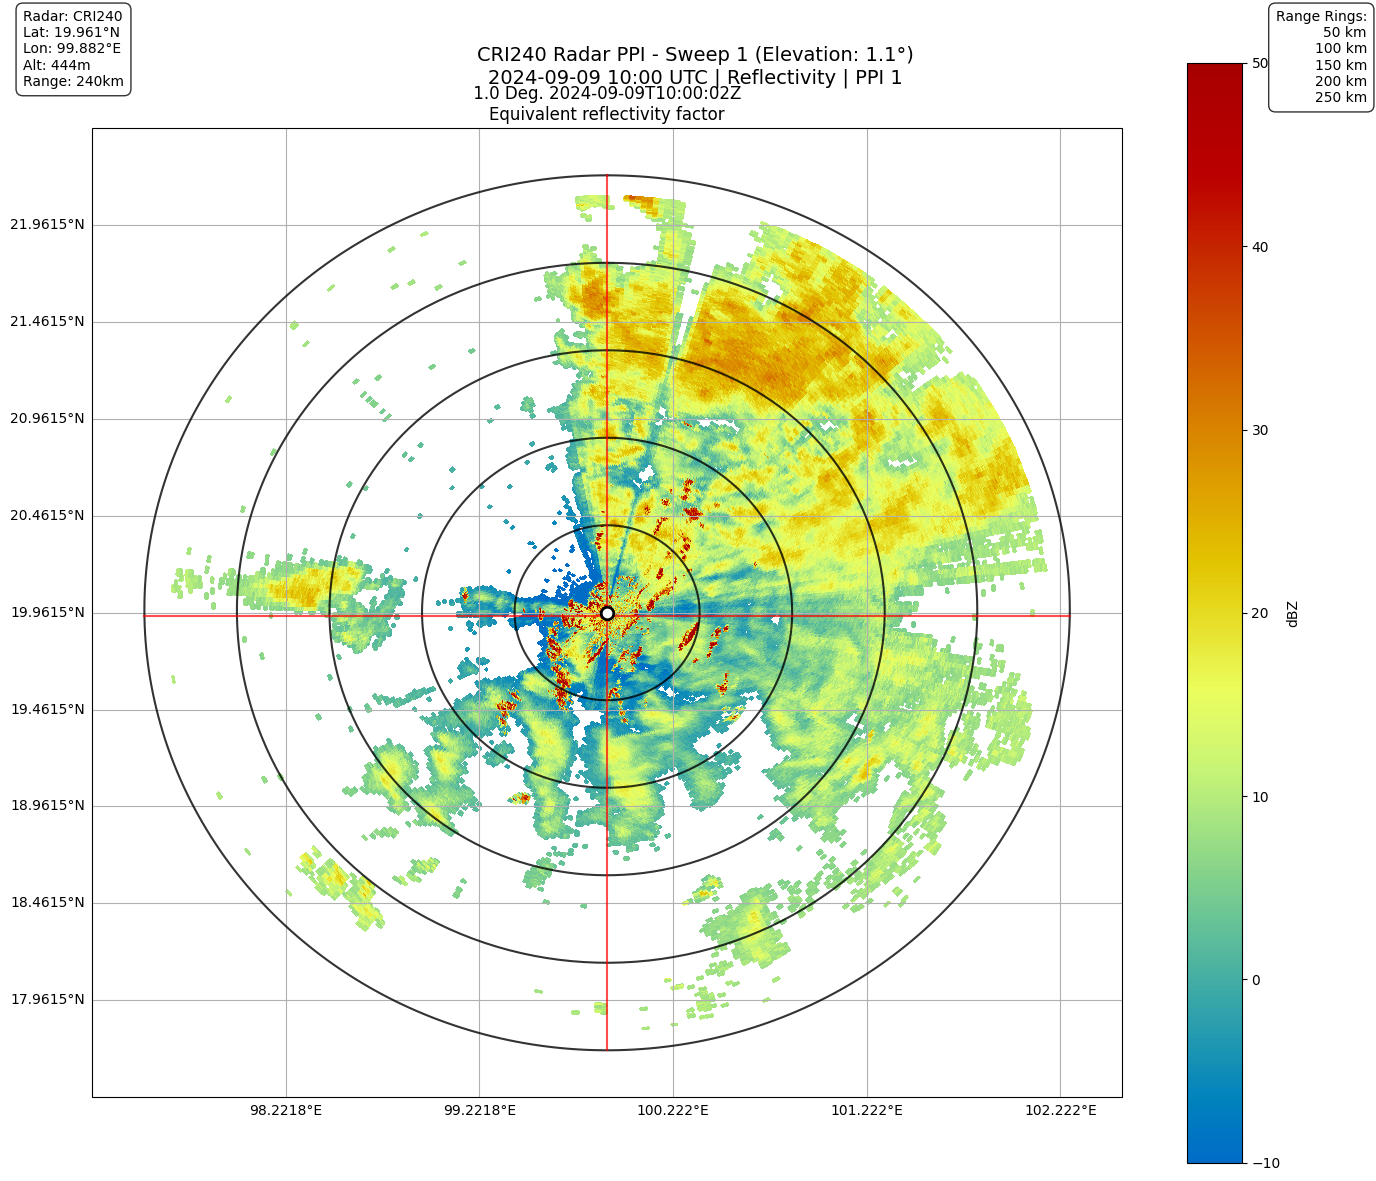


Plotting PPI 2 (Sweep 1)...
Creating PPI geographic plot for sweep 1...
✓ Geographic PPI saved: cri240_ppi_sweep2_geographic.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

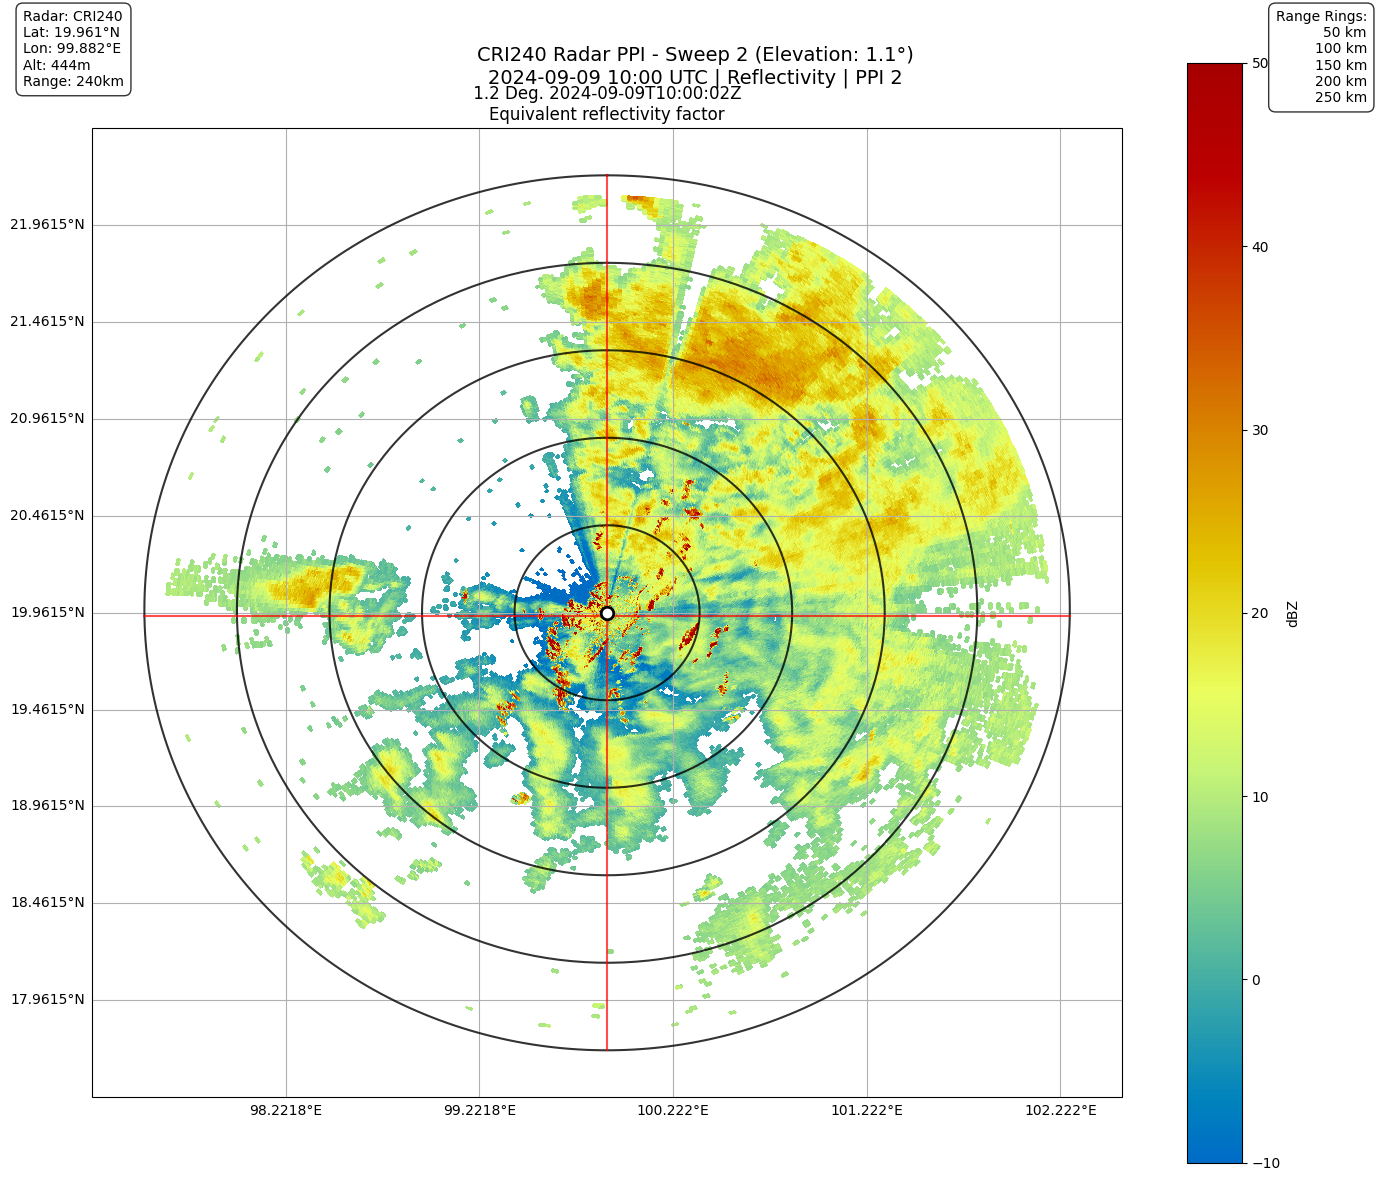

✓ Both PPI plots created successfully!

QUALITY CONTROL PROCESSING
Starting quality control processing...
Applying SNR filter...
Detecting and removing flares...
Removed 1855 flare points
Interpolating missing data...
Applying attenuation correction...
Unfolding
Exec time:  2.185051918029785
Doing  0
Attenuation correction failed: No module named 'glpk'
Using 'flare_removed_reflectivity' as final product.
✓ Quality control processing completed

PLOTTING QUALITY-CONTROLLED PPI DATA

📊 PLOTTING PPI SWEEPS
Found 2 sweeps. Plotting first two...

Plotting PPI 1 (Sweep 0)...
Creating PPI geographic plot for sweep 0...
✓ Geographic PPI saved: cri240_ppi_sweep1_geographic.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

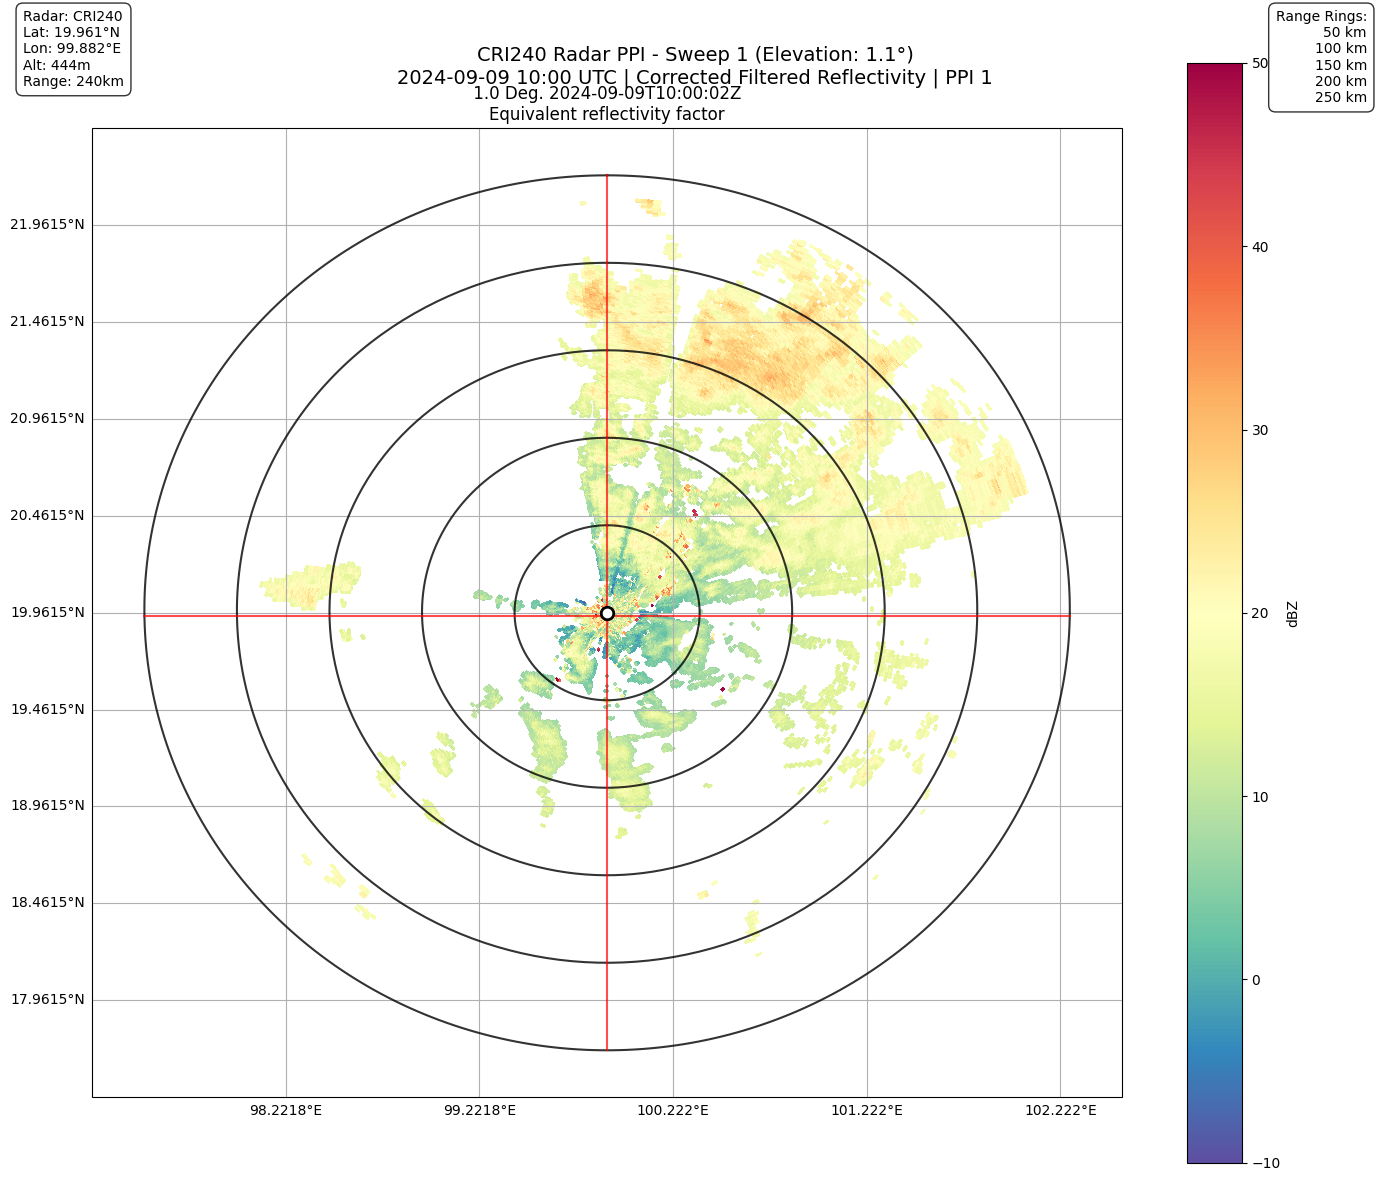


Plotting PPI 2 (Sweep 1)...
Creating PPI geographic plot for sweep 1...
✓ Geographic PPI saved: cri240_ppi_sweep2_geographic.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

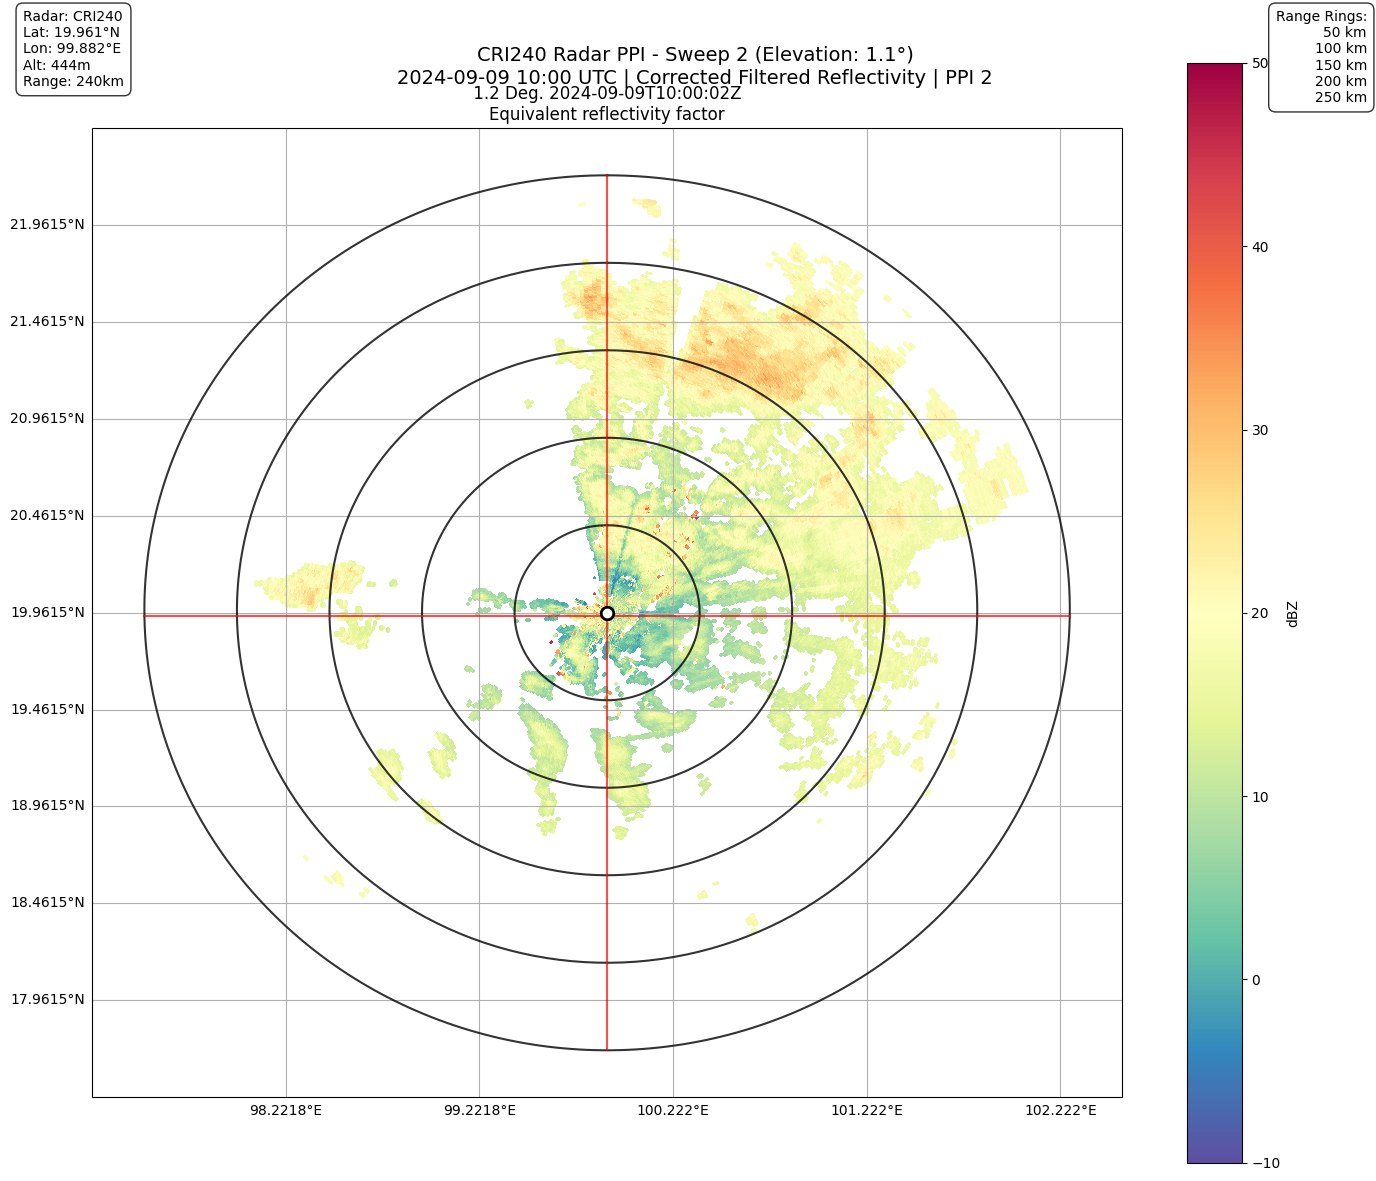

✓ Both PPI plots created successfully!

CREATING CAPPI
Creating CAPPI at 2 km height...
✓ CAPPI created successfully
Creating CAPPI map...
✓ Map saved: cri240_cappi_map.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

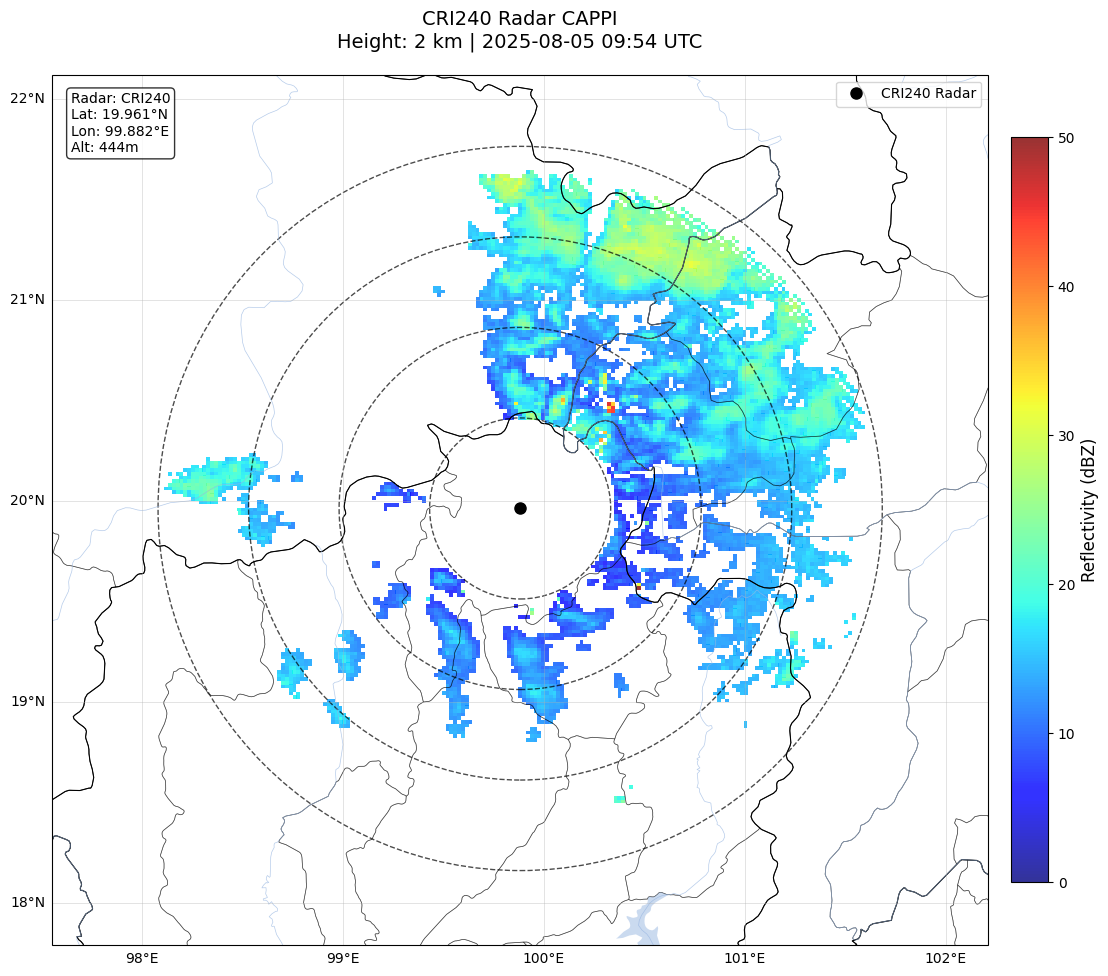


SAVING GEOTIFF


In [11]:
process_cri_radar()